# Snapshot comparison — publications per year, Renly 2026-01-16 vs official 2026-09-23

`paper_metadata.parquet` has one row per work, so its `year` column counted per year is the number of publications
per year that every OpenAlex output here is built on. This notebook compares that count between

| version | file | built from |
|---|---|---|
| **Renly** | `OpenAlex/output_Renly/paper_metadata.parquet` | renli's conversion of the 2026-01-16 snapshot |
| **Sep-23** | `OpenAlex/output/paper_metadata.parquet` | OpenAlex's own parquet export, release 2026-09-23, flattened by `OpenAlex/flatten_snapshot.py` |

**Why they differ.** Renly's conversion kept 372.7M of the snapshot's 476.95M works. It named each output part
after the input file's basename (`part_0000`, ...), and every `updated_date=` folder numbers its files from
`part_0000`, so same-numbered files from different folders overwrote one another (81.3M works), and 301 input files
that failed were never retried (23.0M works). The loss is not uniform in time: the overwritten folders were the most
recently updated ones, which hold most of the newest works. Eight more months of indexing (new 2026 works, late-indexed
2025 works, reclassified years) also separate the two releases, so the gap is **loss + update**, not loss alone; the
2026 bar in particular is mostly new indexing.

**Conventions.** Works with no `publication_year` (null `year`) cannot be placed on the time axis; they are counted in
the table below but not in the curves. Cumulative counts run from the earliest year in the data, so the curve at year
*y* is every dated work published in or before *y*. The plots show 1950–2026; years after 2026 (data errors) are in the
table only.

Section 3 splits the gap id by id into works Renly's conversion lost, works OpenAlex added after January, works
OpenAlex has deleted since, and works whose publication year changed.

Outputs (`OpenAlex/figures/`): `snapshot_comparison_publications.png` / `.csv` (sections 1-2) and
`snapshot_comparison_decomposition.png` / `.csv` (section 3); each CSV is the table view of its figure.

In [1]:
import os, time
import numpy as np, pandas as pd, duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE = '/project/jevans/Dawoon/Science of Science/OpenAlex'
RENLY_FP = os.environ.get('NB_RENLY_SRC', f'{BASE}/output_Renly/paper_metadata.parquet')
NEW_FP = os.environ.get('NB_NEW_SRC', f'{BASE}/output/paper_metadata.parquet')
NEW_COL = os.environ.get('NB_NEW_COL', 'year')     # preview before paper_metadata exists: the flat works table's
                                                   # publication_year (paper_metadata's year is exactly that column)
TAG = os.environ.get('NB_TAG', '')                 # suffix for preview outputs
FIG_DIR = f'{BASE}/figures'
os.makedirs(FIG_DIR, exist_ok=True)
X0, X1 = 1950, 2026

con = duckdb.connect()
con.execute("SET memory_limit='4GB'; SET threads=4")

def per_year(src, col):
    # works per publication year; NULL year kept as its own row
    return con.execute(f'SELECT CAST("{col}" AS INTEGER) AS year, count(*) AS n FROM read_parquet({src!r}) GROUP BY 1').df()

t0 = time.time()
r = per_year(RENLY_FP, 'year').rename(columns={'n': 'renly'})
s = per_year(NEW_FP, NEW_COL).rename(columns={'n': 'sep23'})
print(f'Renly : {RENLY_FP}\nSep-23: {NEW_FP} ({NEW_COL})   [{time.time() - t0:.0f}s]')
tot = pd.DataFrame({'renly': [r.renly.sum(), r.loc[r.year.isna(), 'renly'].sum()],
                    'sep23': [s.sep23.sum(), s.loc[s.year.isna(), 'sep23'].sum()]}, index=['all works', 'no year'])
tot.loc['dated works'] = tot.loc['all works'] - tot.loc['no year']
tot['difference'] = tot.sep23 - tot.renly
print(tot.map(lambda v: f'{v:,}').to_string())

Renly : /project/jevans/Dawoon/Science of Science/OpenAlex/output_Renly/paper_metadata.parquet
Sep-23: /project/jevans/Dawoon/Science of Science/OpenAlex/output/paper_metadata.parquet (year)   [23s]
                   renly        sep23   difference
all works    372,655,605  476,196,327  103,540,722
no year       23,715,388   15,719,824   -7,995,564
dated works  348,940,217  460,476,503  111,536,286


## 1. The table

One row per year: works in each version, the cumulative counts, their difference, and Renly's cumulative count as a
share of Sep-23's.

In [2]:
d = (r.dropna(subset=['year']).merge(s.dropna(subset=['year']), on='year', how='outer')
       .fillna(0).astype({'year': int, 'renly': np.int64, 'sep23': np.int64}).sort_values('year').reset_index(drop=True))
d['diff'] = d.sep23 - d.renly
d['cum_renly'] = d.renly.cumsum()
d['cum_sep23'] = d.sep23.cumsum()
d['cum_diff'] = d.cum_sep23 - d.cum_renly
d['cum_share_pct'] = (d.cum_renly / d.cum_sep23 * 100).round(2)
d.to_csv(f'{FIG_DIR}/snapshot_comparison_publications{TAG}.csv', index=False)

pd.set_option('display.width', 200)
show = d[d.year.between(X0, X1)].copy()
fmt = {c: '{:,}'.format for c in ['renly', 'sep23', 'diff', 'cum_renly', 'cum_sep23', 'cum_diff']}
print(show[show.year >= 1990].to_string(index=False, formatters=fmt))
print(f'\nyears outside {X0}-{X1}: {d.year.min()}-{X0 - 1} and {X1 + 1}-{d.year.max()} '
      f'({d[d.year > X1].renly.sum():,} Renly / {d[d.year > X1].sep23.sum():,} Sep-23 works after {X1})')

def at(y, c):
    return int(d.loc[d.year == y, c].iloc[0])
for y in (2000, 2010, 2015, 2019, 2022, 2025, 2026):
    print(f'by {y}: Renly {at(y, "cum_renly") / 1e6:6.1f}M, Sep-23 {at(y, "cum_sep23") / 1e6:6.1f}M, '
          f'gap {at(y, "cum_diff") / 1e6:+6.1f}M, Renly = {at(y, "cum_renly") / at(y, "cum_sep23") * 100:5.1f}% of Sep-23')

 year      renly      sep23       diff   cum_renly   cum_sep23    cum_diff  cum_share_pct
 1990  1,919,682  2,483,502    563,820  55,209,336  59,384,010   4,174,674          92.97
 1991  1,912,862  2,473,235    560,373  57,122,198  61,857,245   4,735,047          92.35
 1992  2,017,272  2,613,984    596,712  59,139,470  64,471,229   5,331,759          91.73
 1993  2,064,855  2,722,219    657,364  61,204,325  67,193,448   5,989,123          91.09
 1994  2,156,485  2,878,219    721,734  63,360,810  70,071,667   6,710,857          90.42
 1995  2,305,344  3,087,570    782,226  65,666,154  73,159,237   7,493,083          89.76
 1996  2,446,615  3,330,245    883,630  68,112,769  76,489,482   8,376,713          89.05
 1997  2,457,967  3,419,306    961,339  70,570,736  79,908,788   9,338,052          88.31
 1998  2,611,731  3,640,222  1,028,491  73,182,467  83,549,010  10,366,543          87.59
 1999  2,674,205  3,803,094  1,128,889  75,856,672  87,352,104  11,495,432          86.84
 2000  3,3

## 2. The figure

Top row cumulative, bottom row per year; left the two versions, right their difference (Sep-23 minus Renly). The
difference panels are in neutral ink because they belong to neither version.

WROTE /project/jevans/Dawoon/Science of Science/OpenAlex/figures/snapshot_comparison_publications.png


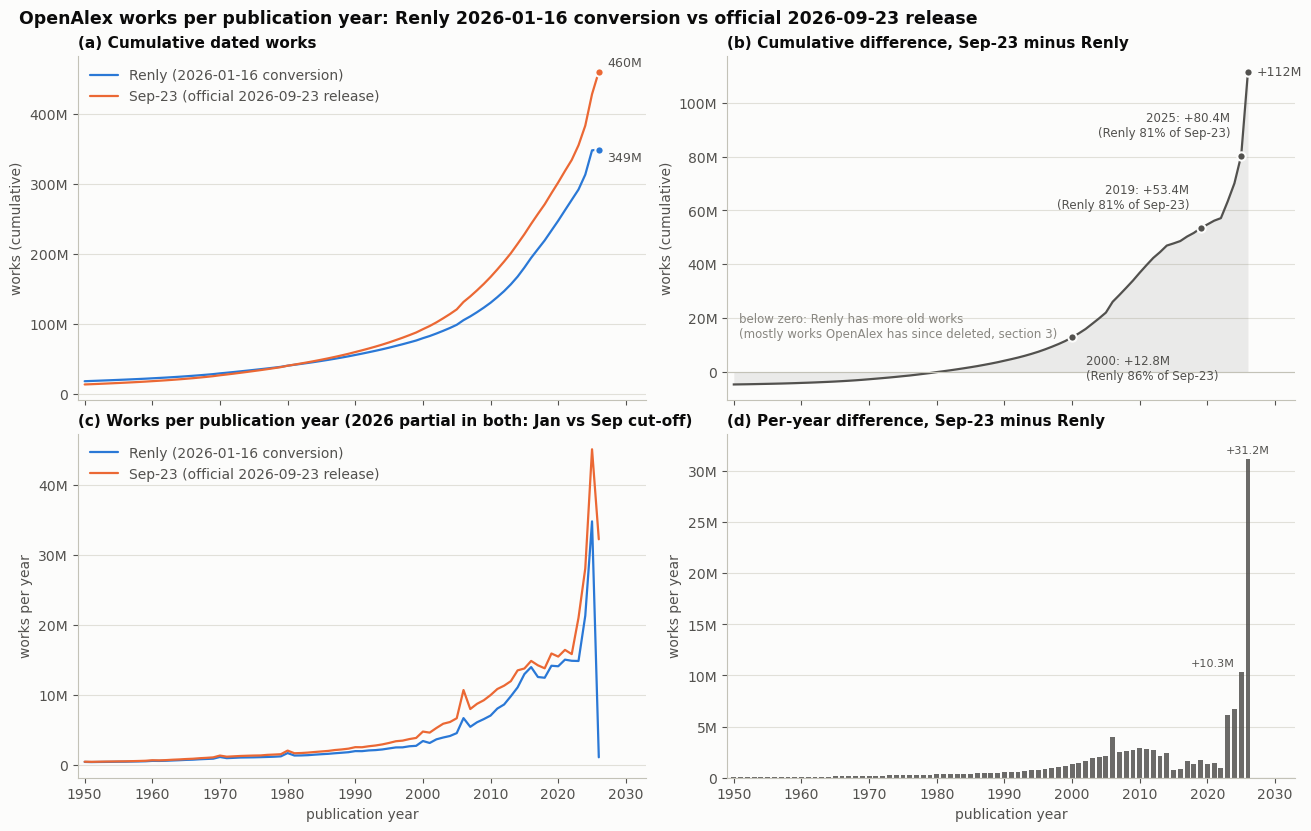

In [3]:
INK, INK2, MUTED, GRID, AXIS, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7', '#fcfcfb'
C = {'renly': '#2a78d6', 'sep23': '#eb6834'}          # categorical slots 1-2 (validated: CVD dE 24.7, normal 33.6)
NAME = {'renly': 'Renly (2026-01-16 conversion)', 'sep23': 'Sep-23 (official 2026-09-23 release)'}
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10, 'axes.edgecolor': AXIS, 'axes.labelcolor': INK2,
                     'xtick.color': INK2, 'ytick.color': INK2, 'axes.titlecolor': INK, 'axes.titleweight': 'bold',
                     'axes.titlesize': 11, 'axes.titlelocation': 'left', 'figure.facecolor': SURF, 'axes.facecolor': SURF})
p = d[d.year.between(X0, X1)]
M = 1e6
fig, ax = plt.subplots(2, 2, figsize=(13, 8.2), sharex=True, constrained_layout=True)

def style(a, ylabel):
    a.grid(axis='y', color=GRID, linewidth=0.8)
    a.set_axisbelow(True)
    for sp in ('top', 'right'):
        a.spines[sp].set_visible(False)
    a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}M' if v else '0'))
    a.set_ylabel(ylabel)
    a.set_xlim(X0 - 1, X1 + 7)
    a.xaxis.set_major_locator(mticker.MultipleLocator(10))

def end_label(a, x, y, txt, color, dy=0):
    a.plot([x], [y], 'o', ms=6, color=color, mec=SURF, mew=1.5, zorder=4)
    a.annotate(txt, (x, y), xytext=(6, dy), textcoords='offset points', va='center', fontsize=9, color=INK2)

# (a) cumulative, both versions
a = ax[0, 0]
for k in ('renly', 'sep23'):
    a.plot(p.year, p[f'cum_{k}'] / M, color=C[k], lw=1.6, label=NAME[k], solid_capstyle='round')
last = p.iloc[-1]
gap = last.cum_sep23 - last.cum_renly
end_label(a, X1, last.cum_sep23 / M, f'{last.cum_sep23 / M:,.0f}M', C['sep23'], dy=6)
end_label(a, X1, last.cum_renly / M, f'{last.cum_renly / M:,.0f}M', C['renly'], dy=-6)
a.set_title('(a) Cumulative dated works')
a.legend(frameon=False, loc='upper left', labelcolor=INK2)
style(a, 'works (cumulative)')

# (b) cumulative difference
a = ax[0, 1]
a.fill_between(p.year, 0, p.cum_diff / M, color=INK2, alpha=0.10, lw=0)
a.plot(p.year, p.cum_diff / M, color=INK2, lw=1.6)
a.axhline(0, color=AXIS, lw=0.8)
for y, dx, dy, ha in ((2000, 10, -30, 'left'), (2019, -8, 14, 'right'), (2025, -8, 14, 'right')):
    v = at(y, 'cum_diff') / M
    a.plot([y], [v], 'o', ms=6, color=INK2, mec=SURF, mew=1.5, zorder=4)
    a.annotate(f'{y}: {v:+,.1f}M\n(Renly {at(y, "cum_renly") / at(y, "cum_sep23") * 100:.0f}% of Sep-23)',
               (y, v), xytext=(dx, dy), textcoords='offset points', ha=ha, fontsize=8.5, color=INK2)
end_label(a, X1, last.cum_diff / M, f'{last.cum_diff / M:+,.0f}M', INK2)
v0 = at(X0, 'cum_diff') / M
if v0 < 0:
    a.annotate('below zero: Renly has more old works\n(mostly works OpenAlex has since deleted, section 3)',
               (X0, v0), xytext=(4, 34), textcoords='offset points', fontsize=8.5, color=MUTED)
a.set_title('(b) Cumulative difference, Sep-23 minus Renly')
style(a, 'works (cumulative)')

# (c) per year, both versions
a = ax[1, 0]
for k in ('renly', 'sep23'):
    a.plot(p.year, p[k] / M, color=C[k], lw=1.6, label=NAME[k], solid_capstyle='round')
a.set_title('(c) Works per publication year (2026 partial in both: Jan vs Sep cut-off)')
a.legend(frameon=False, loc='upper left', labelcolor=INK2)
style(a, 'works per year')

# (d) per-year difference
a = ax[1, 1]
a.bar(p.year, p['diff'] / M, width=0.72, color=INK2, alpha=0.85, lw=0)
a.axhline(0, color=AXIS, lw=0.8)
for y, ha, dx in ((2025, 'right', -5), (2026, 'center', 0)):   # 2025's label sits left, clear of the 2026 bar
    v = at(y, 'diff') / M
    a.annotate(f'{v:+.1f}M', (y, v), xytext=(dx, 4), textcoords='offset points', ha=ha, fontsize=8, color=INK2)
a.set_ylim(top=p['diff'].max() / M * 1.08)
a.set_title('(d) Per-year difference, Sep-23 minus Renly')
style(a, 'works per year')
for a in ax[1]:
    a.set_xlabel('publication year')

fig.suptitle('OpenAlex works per publication year: Renly 2026-01-16 conversion vs official 2026-09-23 release',
             x=0.01, ha='left', fontsize=12.5, fontweight='bold', color=INK)
out = f'{FIG_DIR}/snapshot_comparison_publications{TAG}.png'
fig.savefig(out, dpi=200, facecolor=SURF)
print('WROTE', out)
plt.show()

## 3. Where the gap comes from

Every work is matched by id between the two `paper_metadata` files. A work can be

| component | meaning | sign in the per-year gap |
|---|---|---|
| **lost by Renly's conversion** | in Sep-23, not in Renly, created before the January snapshot (`created_date` < 2026-01-15; the snapshot's newest folder is `updated_date=2026-01-14`) | + |
| **added after January** | in Sep-23, not in Renly, created on or after 2026-01-15 | + |
| **deleted by OpenAlex since** | in Renly, not in Sep-23 (checked against the release's `works/deleted_ids.csv.gz`) | − |
| **re-dated** | in both, with a different `publication_year`: −1 in the old year, +1 in the new one | ± (sums to 0) |

so that, for every year, Sep-23 − Renly = lost + added − deleted + re-dated (net). `created_date` is a proxy: OpenAlex
re-created some old works (about 0.4% of the shared works carry a `created_date` after January), so the split between
*lost* and *added* is approximate; the total of each year is exact.

In [4]:
SNAP = os.environ.get('NB_SNAPSHOT', '/project/jevans/OpenAlex_shared/OpenAlex_2026_Sep_23')   # nested release
NEW_IDCOL = os.environ.get('NB_NEW_IDCOL', 'paper_id')
CUT = '2026-01-15'
t0 = time.time()
os.makedirs(f'{BASE}/cache/duckdb_tmp_compare', exist_ok=True)
cx = duckdb.connect()
cx.execute(f"SET threads={os.environ.get('SLURM_CPUS_PER_TASK', '8')}; SET memory_limit='{os.environ.get('NB_DUCKDB_MEM', '150GB')}'; "
           f"SET preserve_insertion_order=false; SET temp_directory='{BASE}/cache/duckdb_tmp_compare'")
# every row is kept, so the components add up to section 1's counts; a malformed id (renli's tree has one
# placeholder, 'W-1') becomes a code no real work has and lands in its version's "only" column
cx.execute(f"""CREATE TABLE r AS SELECT coalesce(TRY_CAST(substr(paper_id, 2) AS BIGINT), -1) c, CAST(year AS INT) y
               FROM read_parquet('{RENLY_FP}')""")
cx.execute(f"""CREATE TABLE n AS SELECT coalesce(TRY_CAST(substr({NEW_IDCOL}, 2) AS BIGINT), -2) c, CAST("{NEW_COL}" AS INT) y
               FROM read_parquet('{NEW_FP}')""")
print('malformed ids: Renly', cx.execute('SELECT count(*) FILTER (WHERE c < 0) FROM r').fetchone()[0],
      '| Sep-23', cx.execute('SELECT count(*) FILTER (WHERE c < 0) FROM n').fetchone()[0])
# created_date lives only in the nested release. hive_partitioning=false, or the updated_date= folder names would
# be read as a column that clashes with the files' own updated_date.
cx.execute(f"""CREATE TABLE cd AS SELECT CAST(replace(id, 'https://openalex.org/W', '') AS BIGINT) c,
               created_date < TIMESTAMP '{CUT}' AS before_cut
               FROM read_parquet('{SNAP}/works/*/*.parquet', hive_partitioning=false)""")
cx.execute(f"""CREATE TABLE del AS SELECT DISTINCT CAST(replace(work_id, 'https://openalex.org/W', '') AS BIGINT) c
               FROM read_csv('{SNAP}/works/deleted_ids.csv.gz', header=true)""")
cx.execute("""CREATE TABLE j AS
  SELECT coalesce(r.c, n.c) c, r.y ry, n.y ny, r.c IS NOT NULL in_r, n.c IS NOT NULL in_n,
         cd.before_cut, del.c IS NOT NULL deleted
  FROM r FULL OUTER JOIN n ON r.c = n.c
  LEFT JOIN cd ON cd.c = coalesce(r.c, n.c) LEFT JOIN del ON del.c = coalesce(r.c, n.c)""")
print(f'matched in {time.time() - t0:.0f}s')
cat = cx.execute("""SELECT CASE WHEN in_r AND in_n THEN 'in both' WHEN in_r THEN 'Renly only' ELSE 'Sep-23 only' END AS works,
       count(*) AS n,
       count(*) FILTER (WHERE in_r AND in_n AND ry IS NOT DISTINCT FROM ny) AS same_year,
       count(*) FILTER (WHERE deleted) AS in_deleted_ids,
       count(*) FILTER (WHERE in_n AND NOT before_cut) AS created_after_cut
  FROM j GROUP BY 1 ORDER BY 1""").df()
print(cat.to_string(index=False, formatters={c: '{:,}'.format for c in cat.columns[1:]}))

comp = cx.execute("""
WITH a AS (SELECT ny AS year, count(*) FILTER (WHERE NOT in_r AND before_cut)     AS lost,
                              count(*) FILTER (WHERE NOT in_r AND NOT before_cut) AS added,
                              count(*) FILTER (WHERE in_r) AS shared_new FROM j WHERE in_n GROUP BY 1),
     b AS (SELECT ry AS year, count(*) FILTER (WHERE NOT in_n) AS deleted,
                              count(*) FILTER (WHERE in_n) AS shared_old FROM j WHERE in_r GROUP BY 1)
SELECT coalesce(a.year, b.year) AS year, coalesce(lost, 0) AS lost, coalesce(added, 0) AS added,
       coalesce(deleted, 0) AS deleted, coalesce(shared_new, 0) - coalesce(shared_old, 0) AS redated
FROM a FULL OUTER JOIN b ON a.year IS NOT DISTINCT FROM b.year ORDER BY 1""").df()
comp['gap'] = comp.lost + comp.added - comp.deleted + comp.redated
chk = comp.dropna(subset=['year']).astype({'year': int}).merge(d[['year', 'diff']], on='year', how='outer').fillna(0)
bad = chk[chk.gap != chk['diff']]
if len(bad):
    print(bad.to_string())
assert bad.empty, 'components do not add up to the per-year difference'
comp.to_csv(f'{FIG_DIR}/snapshot_comparison_decomposition{TAG}.csv', index=False)

bins = [-10**9, 1950, 1980, 2000, 2010, 2020, 2023, 2025, 2026, 10**9]
lab = ['<1950', '1950-79', '1980-99', '2000-09', '2010-19', '2020-22', '2023-24', '2025', '2026+']
comp['period'] = pd.cut(comp.year.fillna(-10**8), bins, right=False, labels=lab).astype(str)
comp.loc[comp.year.isna(), 'period'] = 'no year'
g = comp.groupby('period', sort=False)[['lost', 'added', 'deleted', 'redated', 'gap']].sum()
g.loc['total'] = g.sum()
print('\nmillions of works (gap = lost + added - deleted + redated = Sep-23 minus Renly):')
print((g / 1e6).round(2).to_string())

malformed ids: Renly 1 | Sep-23 0
matched in 157s
      works           n   same_year in_deleted_ids created_after_cut
 Renly only  41,097,497           0     41,020,851                 0
Sep-23 only 144,638,219           0              0        46,272,747
    in both 331,558,108 319,820,901              0         1,363,129

millions of works (gap = lost + added - deleted + redated = Sep-23 minus Renly):
          lost  added  deleted  redated     gap
period                                         
<1950     1.52   1.11     4.73    -2.58   -4.68
1950-79   4.54   1.18     1.89     0.44    4.27
1980-99  10.71   1.78     1.78     1.21   11.91
2000-09  20.64   2.07     2.32     2.05   22.44
2010-19  27.47   4.04     9.31    -2.75   19.46
2020-22   6.41   1.62     3.55    -0.74    3.73
2023-24  14.35   1.39     2.67    -0.14   12.94
2025      8.51   2.10     0.25    -0.05   10.31
2026+     2.42  28.67     0.00     0.08   31.17
no year   1.79   2.33    14.59     2.48   -8.00
total    98.37  

WROTE /project/jevans/Dawoon/Science of Science/OpenAlex/figures/snapshot_comparison_decomposition.png


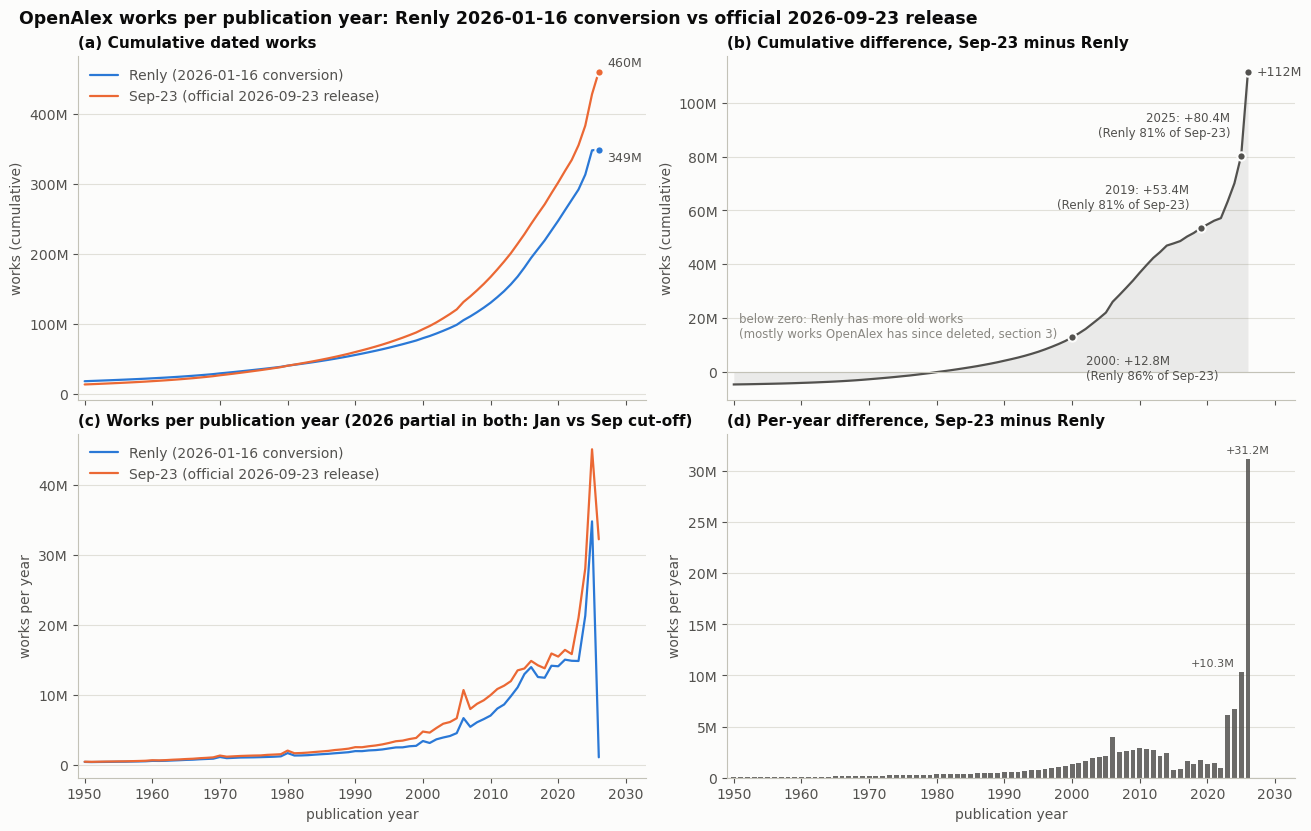

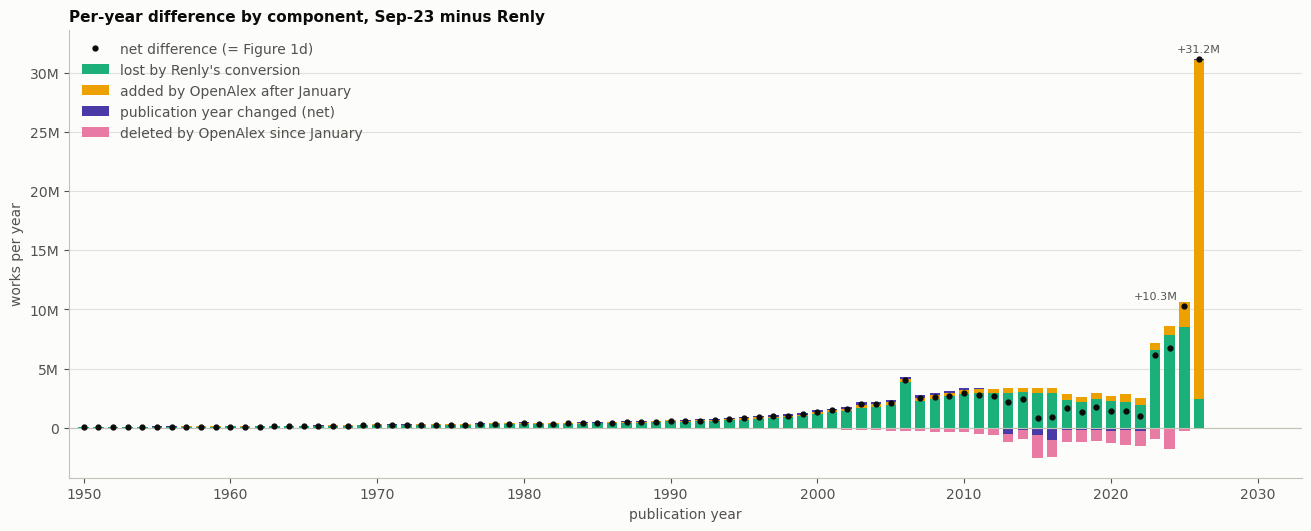

In [5]:
CC = {'lost': '#1baf7a', 'added': '#eda100', 'redated': '#4a3aa7', 'deleted': '#e87ba4'}  # slots 3,4,7,5 in this order: adjacent pairs validated
LAB = {'lost': "lost by Renly's conversion", 'added': 'added by OpenAlex after January',
       'redated': 'publication year changed (net)', 'deleted': 'deleted by OpenAlex since January'}
q = comp.dropna(subset=['year']).astype({'year': int})
q = q[q.year.between(X0, X1)].set_index('year')
fig, a = plt.subplots(figsize=(13, 5.2), constrained_layout=True)
up = np.zeros(len(q)); dn = np.zeros(len(q))
for k in ('lost', 'added', 'redated', 'deleted'):
    v = (-q[k] if k == 'deleted' else q[k]).to_numpy() / M
    pos, neg = np.clip(v, 0, None), np.clip(v, None, 0)
    a.bar(q.index, pos, bottom=up, width=0.72, color=CC[k], label=LAB[k], lw=0)
    a.bar(q.index, neg, bottom=dn, width=0.72, color=CC[k], lw=0)
    up += pos; dn += neg
a.plot(q.index, q.gap / M, 'o', ms=3.5, color=INK, label='net difference (= Figure 1d)', zorder=4)
a.axhline(0, color=AXIS, lw=0.8)
for y, ha, dx in ((2025, 'right', -5), (2026, 'center', 0)):   # 2025's label sits left, clear of the 2026 bar
    a.annotate(f'{q.gap[y] / M:+.1f}M', (y, q.gap[y] / M), xytext=(dx, 5), textcoords='offset points', ha=ha,
               fontsize=8, color=INK2)
a.set_ylim(top=max(up.max(), q.gap.max() / M) * 1.08)
style(a, 'works per year')
a.set_xlabel('publication year')
a.set_title('Per-year difference by component, Sep-23 minus Renly')
a.legend(frameon=False, loc='upper left', labelcolor=INK2)
out = f'{FIG_DIR}/snapshot_comparison_decomposition{TAG}.png'
fig.savefig(out, dpi=200, facecolor=SURF)
print('WROTE', out)
plt.show()